In [ ]:
import json
import matplotlib.pyplot as plt

In [ ]:
# the structure of trajectory relevant data in the JSON file is as follows:
# {
#     "tracks": [
#         {
#             "mode": "person",
#             "frames": [
#                 {"frame_num": 0, "time_sec": 0.0, "projected_point": [1.0, 2.0]},
#                 {"frame_num": 1, "time_sec": 0.033, "projected_point": [1.5, 2.5]},
#             ],
#         },
#         {
#             "mode": "vehicle-pos",
#             "frames": [
#                 {"frame_num": 0, "time_sec": 0.0, "projected_point": [1.0, 2.0]},
#                 {"frame_num": 1, "time_sec": 0.033, "projected_point": [1.5, 2.5]},
#             ],
#         },
#     ],
#     "projected_polygon": [
#         [1.0, 2.0],
#         [1.5, 2.5],
#         [2.0, 3.0],
#         [1.0, 2.0],
#     ]
# }

# the polygon refers to the crosswalk area
# the points are transformed to a common coordinate system, so they can be plotted together
# the centroid of the polygon is the center of the crosswalk area
# the unit of the coordinates is in meters

In [24]:
def plot_polygon_and_lines_from_json(json_file, line_number=None):
    with open(json_file, 'r') as f:
        data = json.load(f)

    points = data.get('projected_polygon', [])
    if not points:
        print("No points found in the JSON file.")
        return

    # Polygon
    x_coords = [point[0] for point in points] + [points[0][0]]
    y_coords = [point[1] for point in points] + [points[0][1]]

    plt.figure()

    # Plot polygon
    plt.plot(x_coords, y_coords, marker='o', label='Crosswalk Polygon', color='black')

    # Plot line(s)
    if line_number is not None:
        tracks = data.get('tracks', [])
        if line_number < len(tracks):
            frames = tracks[line_number].get('frames', [])
            line_x_coords = [frame['projected_point'][0] for frame in frames]
            line_y_coords = [frame['projected_point'][1] for frame in frames]
            plt.plot(line_x_coords, line_y_coords, label=f'Pedestrian {line_number}')
        else:
            print(f"Line number {line_number} is out of range. Total lines: {len(tracks)}")

    plt.title('Polygon and Line from JSON')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid()
    plt.axis('equal')
    plt.legend()
    plt.show()

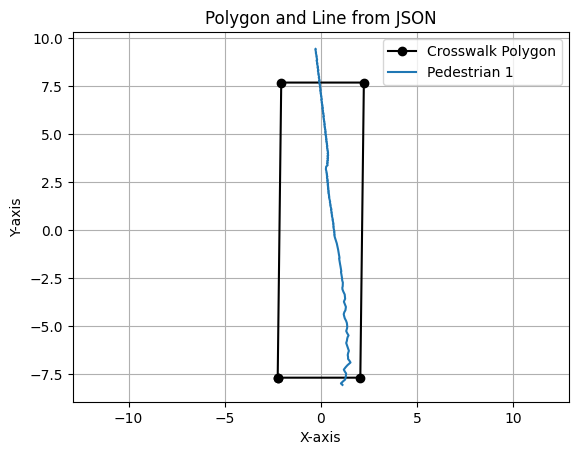

In [26]:
plot_polygon_and_lines_from_json(r"C:\Users\abhis\Box\CUSP_Capstone_2025\Videos\3rd_ave_and_37th_st\3rd_ave_and_37th_st_004.json", 1)